# 01 — Data exploration

## What this notebook does
You learn how river water-quality datasets are structured for **geospatial ML**: coordinates, targets (what you measure in the river), and optional environmental predictors sampled at the same place/time.

## Why it matters
Exploratory analysis checks **missing data**, **outliers**, and **spatial coverage**. Poor coverage or duplicated sites can bias models. Maps reveal whether samples span the region you want to generalize to.

## Scientific reasoning
Water chemistry is controlled by **catchment processes** (rainfall, geology, land use). Your points are **observations of a spatial process** — not i.i.d. draws — so later we use **spatial cross-validation**.


In [9]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if not (ROOT / "data" / "raw").exists():
    ROOT = ROOT.parent
RAW = ROOT / "data" / "raw"
# Try project CSV names (same order as pipeline)
for name in ["water_quality_dataset_v1.csv", "water_quality.csv"]:
    csv = RAW / name
    if csv.exists():
        break
else:
    csv = None

if csv is None:
    df = None
    print("No CSV found in data/raw/. Add water_quality_dataset_v1.csv or water_quality.csv")
    print("Or run: py scripts/prepare_sample_dataset.py <folder_with_aligned_CSVs>")
else:
    df = pd.read_csv(csv)
    if "Latitude" in df.columns and "lat" not in df.columns:
        df["lat"] = df["Latitude"]
    if "Longitude" in df.columns and "lon" not in df.columns:
        df["lon"] = df["Longitude"]
    for old, new in [("Total Alkalinity", "total_alkalinity"), ("Electrical Conductance", "electrical_conductance"), ("Dissolved Reactive Phosphorus", "dissolved_reactive_phosphorus")]:
        if old in df.columns and new not in df.columns:
            df[new] = df[old]
    print("Loaded:", csv.name, "| Shape:", df.shape)
    display(df.head())
    display(df.describe())

Loaded: water_quality_dataset_v1.csv | Shape: (9319, 41)


,Latitude,Longitude,Sample Date,Total Alkalinity,Electrical Conductance,Dissolved Reactive Phosphorus,pet,elevation,EVI,NDVI,...,NDVI_LST_interaction,flow_acc_clay_interaction,flow_acc_phosphorous_interaction,evaporation_precipitation_ratio,cec_clay_ratio,lat,lon,total_alkalinity,electrical_conductance,dissolved_reactive_phosphorus
0,-28.760833,17.730278,02-01-2011,128.912,555.0,10.0,174.2,167.155040,241.0,636.0,...,10077420.0,8.676030e+07,9.502319e+07,-37.216627,1.142857,-28.760833,17.730278,128.912,555.0,10.0
1,-26.861111,28.884722,03-01-2011,74.720,162.9,163.0,124.1,1521.251493,4643.0,7656.0,...,116294640.0,3.369889e+05,2.440265e+05,-0.523901,0.931034,-26.861111,28.884722,74.720,162.9,163.0
2,-26.450000,28.085833,03-01-2011,89.254,573.0,80.0,127.5,1471.379902,3984.0,6276.0,...,93380604.0,2.800000e+01,2.100000e+01,-0.575803,0.821429,-26.450000,28.085833,89.254,573.0,80.0
3,-27.671111,27.236944,03-01-2011,82.000,203.6,101.0,129.7,1342.659998,2217.0,3957.0,...,60259174.5,4.884100e+05,4.132700e+05,-0.538889,0.884615,-27.671111,27.236944,82.000,203.6,101.0
4,-27.356667,27.286389,03-01-2011,56.100,145.1,151.0,129.2,1355.983661,4136.0,7396.0,...,111901480.0,1.337840e+05,9.556000e+04,-0.784851,0.892857,-27.356667,27.286389,56.100,145.1,151.0


,Latitude,Longitude,Total Alkalinity,Electrical Conductance,Dissolved Reactive Phosphorus,pet,elevation,EVI,NDVI,Land Surface Temperature,...,NDVI_LST_interaction,flow_acc_clay_interaction,flow_acc_phosphorous_interaction,evaporation_precipitation_ratio,cec_clay_ratio,lat,lon,total_alkalinity,electrical_conductance,dissolved_reactive_phosphorus
count,9319.000000,9319.000000,9319.000000,9319.000000,9319.000000,9319.000000,9319.000000,9319.000000,9319.000000,9319.000000,...,9.319000e+03,9.319000e+03,9.319000e+03,9023.000000,9319.000000,9319.000000,9319.000000,9319.000000,9319.000000,9319.000000
mean,-28.474988,26.868414,119.108208,485.004146,43.525338,175.166082,912.703348,2458.096952,4493.927943,15062.102264,...,6.770584e+07,1.977543e+06,1.860769e+06,-130.540551,0.908456,-28.474988,26.868414,119.108208,485.004146,43.525338
std,2.760282,3.535164,74.692591,341.937736,50.980194,29.469867,514.992034,1057.067224,1560.694366,358.526816,...,2.354739e+07,7.929163e+06,8.429034e+06,223.473275,0.089757,2.760282,3.535164,74.692591,341.937736,50.980194
min,-34.405833,17.730278,4.800000,15.120000,5.000000,52.700000,5.545029,-402.000000,-884.000000,14164.000000,...,-1.322376e+07,2.000000e+01,1.900000e+01,-2184.693150,0.555556,-34.405833,17.730278,4.800000,15.120000,5.000000
25%,-30.160091,26.126667,55.811000,207.050000,10.000000,156.100000,388.516336,1599.250000,3167.750000,14785.000000,...,4.770171e+07,1.455227e+04,1.455227e+04,-157.697458,0.866667,-30.160091,26.126667,55.811000,207.050000,10.000000
50%,-28.058889,27.409060,113.300000,402.000000,20.000000,172.500000,1083.049521,2305.500000,4432.000000,15079.500000,...,6.688051e+07,2.107875e+05,1.659200e+05,-27.405954,0.916667,-28.058889,27.409060,113.300000,402.000000,20.000000
75%,-26.861111,29.245556,170.230000,693.000000,48.000000,193.100000,1320.711972,3126.000000,5677.750000,15317.500000,...,8.559962e+07,9.773660e+05,9.010066e+05,-4.731636,0.961538,-26.861111,29.245556,170.230000,693.000000,48.000000
max,-22.225556,32.325000,361.676000,1506.000000,195.000000,270.800020,1598.033353,6894.000000,8665.000000,16267.000000,...,1.311794e+08,8.676030e+07,9.502319e+07,-0.194201,1.238095,-22.225556,32.325000,361.676000,1506.000000,195.000000


## Map sampling points
**Why:** Visual inspection shows clusters, gaps, and whether you sample one river network or many. **Interpretation:** Dense clusters mean correlated environments — random splits would leak information between train and test.


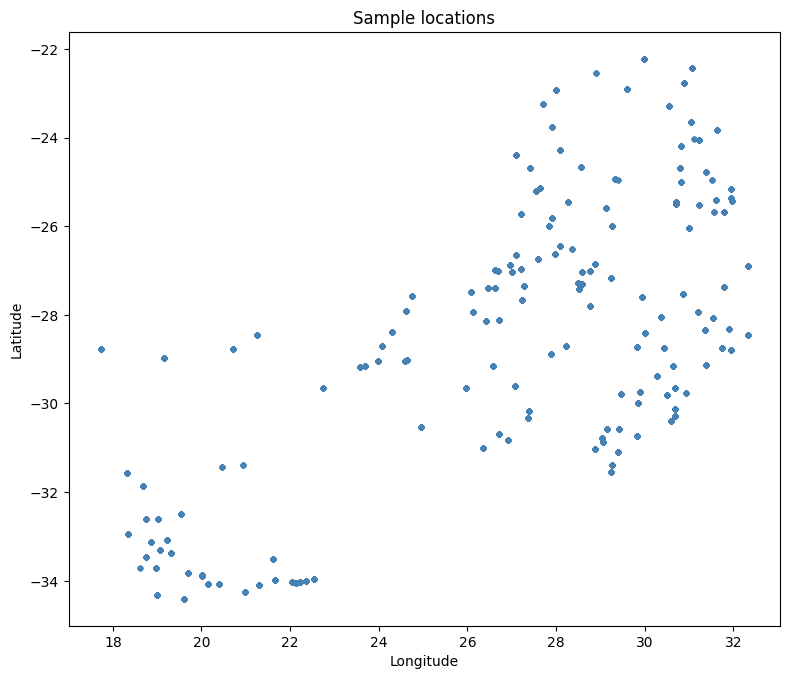

In [10]:
if df is not None and len(df) > 0:
    lat = df.get("lat", df.get("Latitude"))
    lon = df.get("lon", df.get("Longitude"))
    if lat is not None and lon is not None:
        sys.path.insert(0, str(ROOT))
        from src.visualization.maps import plot_sampling_points
        plot_sampling_points(lon.values, lat.values, title="Sample locations")
        plt.show()
else:
    print("Run the cell above to load data first (water_quality_dataset_v1.csv or water_quality.csv in data/raw/).")


## Check target distributions
**Why:** Strong skew may suggest log transforms. **Science:** Nutrients and salinity often span orders of magnitude; dilution vs evaporation creates heavy tails.


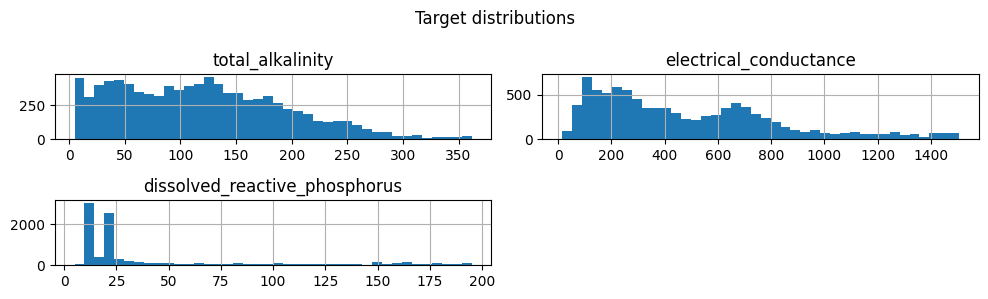

In [11]:
if df is None or len(df) == 0:
    print("Load data in the first code cell (data/raw/water_quality_dataset_v1.csv or water_quality.csv).")
else:
    targets = [c for c in ["total_alkalinity","electrical_conductance","dissolved_reactive_phosphorus"] if c in df.columns]
    if targets:
        df[targets].hist(bins=40, figsize=(10,3))
        plt.suptitle("Target distributions")
        plt.tight_layout()
        plt.show()
    else:
        print("No target columns found. Expected at least one of: total_alkalinity, electrical_conductance, dissolved_reactive_phosphorus")
